Iteration    0 | Loss: 28148711615.5157
Iteration  100 | Loss: 6428462204.4410
Iteration  200 | Loss: 3407780742.3855
Iteration  300 | Loss: 2924900807.8507
Iteration  400 | Loss: 2800275885.5155
Iteration  500 | Loss: 2734588405.0942
Iteration  600 | Loss: 2684863844.0684
Iteration  700 | Loss: 2643766794.5008
Iteration  800 | Loss: 2609189695.4209
Iteration  900 | Loss: 2579960054.2125

Final weights (theta):
[207185.74888449 -43506.87438121 -48761.81298927  20552.84097594
  -4440.05241154  22169.14141597 -32668.83143497  22408.03638203
  78860.51956515]

Test MSE : 5271411984.5956
Test R^2 : 0.5977

sklearn LinearRegression R^2: 0.6139

Saved plots to gradient_descent_plots.png


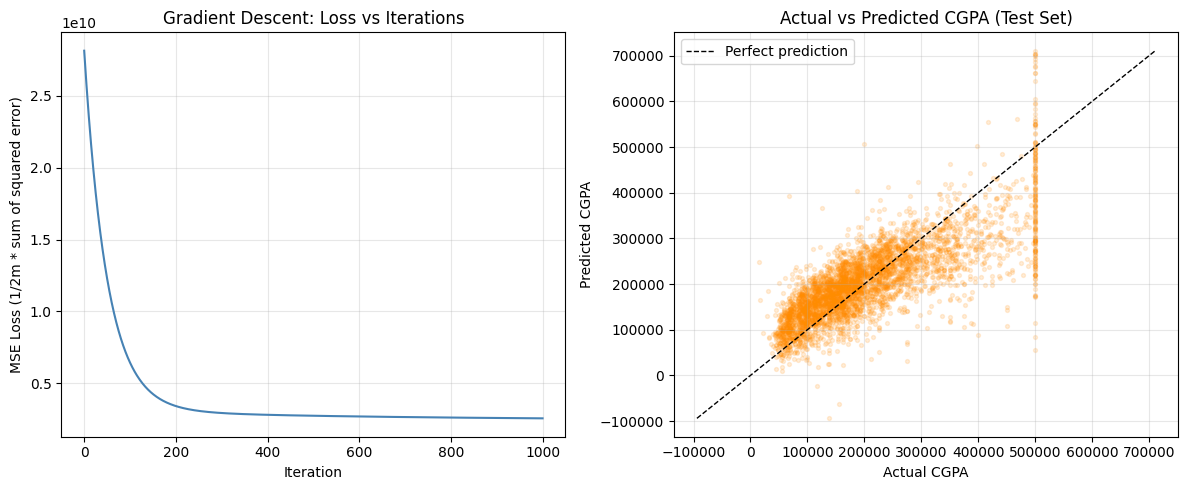

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------------
# 1. Load Dataset
# ---------------------------------------------------------------

df = pd.read_csv("/content/housing.csv")

print("Dataset shape:", df.shape)
print("\nDataset columns:")
print(df.columns)

# Target column
target_col = "median_house_value"

# ---------------------------------------------------------------
# 2. Data Preprocessing
# ---------------------------------------------------------------

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col].values.reshape(-1, 1)

# Convert categorical column into numerical columns
X = pd.get_dummies(X, columns=["ocean_proximity"], dtype=float)

# Handle missing values using median
X = X.fillna(X.median())

# Convert to NumPy array
X = X.values

print("\nNumber of features after preprocessing:", X.shape[1])

# ---------------------------------------------------------------
# 3. Train/Test Split
# ---------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ---------------------------------------------------------------
# 4. Feature Scaling
# ---------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Add bias/intercept column
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# ---------------------------------------------------------------
# 5. Gradient Descent Implementation
# ---------------------------------------------------------------

def gradient_descent(X, y, lr=0.01, n_iters=1000):

    m, n = X.shape

    # Initialize weights
    theta = np.zeros((n, 1))

    losses = []

    for i in range(n_iters):

        # Prediction
        y_pred = X @ theta

        # Error
        error = y_pred - y

        # Mean Squared Error Loss
        loss = (1 / (2 * m)) * np.sum(error ** 2)

        losses.append(loss)

        # Gradient
        gradient = (1 / m) * (X.T @ error)

        # Update weights
        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses


# Train the model
theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)

# ---------------------------------------------------------------
# 6. Prediction
# ---------------------------------------------------------------

y_pred = X_test_b @ theta

# ---------------------------------------------------------------
# 7. Evaluation
# ---------------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())

print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")

# ---------------------------------------------------------------
# 8. Compare with sklearn Linear Regression
# ---------------------------------------------------------------

from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()

sk_model.fit(X_train, y_train)

sk_pred = sk_model.predict(X_test)

sk_r2 = r2_score(y_test, sk_pred)

print(f"\nsklearn LinearRegression R^2: {sk_r2:.4f}")

# ---------------------------------------------------------------
# 9. Plots
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss curve
axes[0].plot(range(len(losses)), losses)

axes[0].set_title("Gradient Descent: Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(alpha=0.3)

# Actual vs Predicted
axes[1].scatter(
    y_test,
    y_pred,
    alpha=0.15,
    s=8
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[1].plot(
    lims,
    lims,
    linestyle="--",
    linewidth=1,
    label="Perfect prediction"
)

axes[1].set_title("Actual vs Predicted House Value")
axes[1].set_xlabel("Actual House Value")
axes[1].set_ylabel("Predicted House Value")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "gradient_descent_housing_plots.png",
    dpi=150
)

print("\nSaved plots to gradient_descent_housing_plots.png")

plt.show()